# R10 — ML Prediction Quality

**Goal:** Evaluate the 3 distilled GBM models using internal.csv predictions
vs actual observed values from the same ticks.

### Models evaluated:
1. **Fire Power Predictor** — `predicted_fire_power` vs `opponent_fire_power`
2. **Movement Predictor** — `predicted_lat_vel_5` vs `opponent_lateral_velocity` (lagged)
3. **Fire Timing Predictor** — `predicted_opponent_fires_3` vs `opponent_fired`

### Key metrics:
- Prediction confidence levels
- Calibration: do predicted probabilities match actual rates?
- Distribution overlap between predicted and actual values

In [1]:
import sys; sys.path.insert(0, '..')
from retrospective._retro_helpers import load_local_internal
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['figure.dpi'] = 100

df = load_local_internal()
if df.empty:
    print('No internal.csv data found (CI mode). Skipping R10.')
    import sys; sys.exit(0)
print(f'Loaded {len(df):,} internal ticks from {df.battle_id.nunique()} battles')

# Quick check which prediction columns exist
pred_cols = [c for c in df.columns if c.startswith('predicted_')]
print(f'Prediction columns: {pred_cols}')

Loaded 268,377 internal ticks from 48 battles
Prediction columns: ['predicted_fire_power', 'predicted_fire_power_confidence', 'predicted_lat_vel_5', 'predicted_lat_vel_5_confidence', 'predicted_opponent_fires_3', 'predicted_opponent_fires_3_confidence']


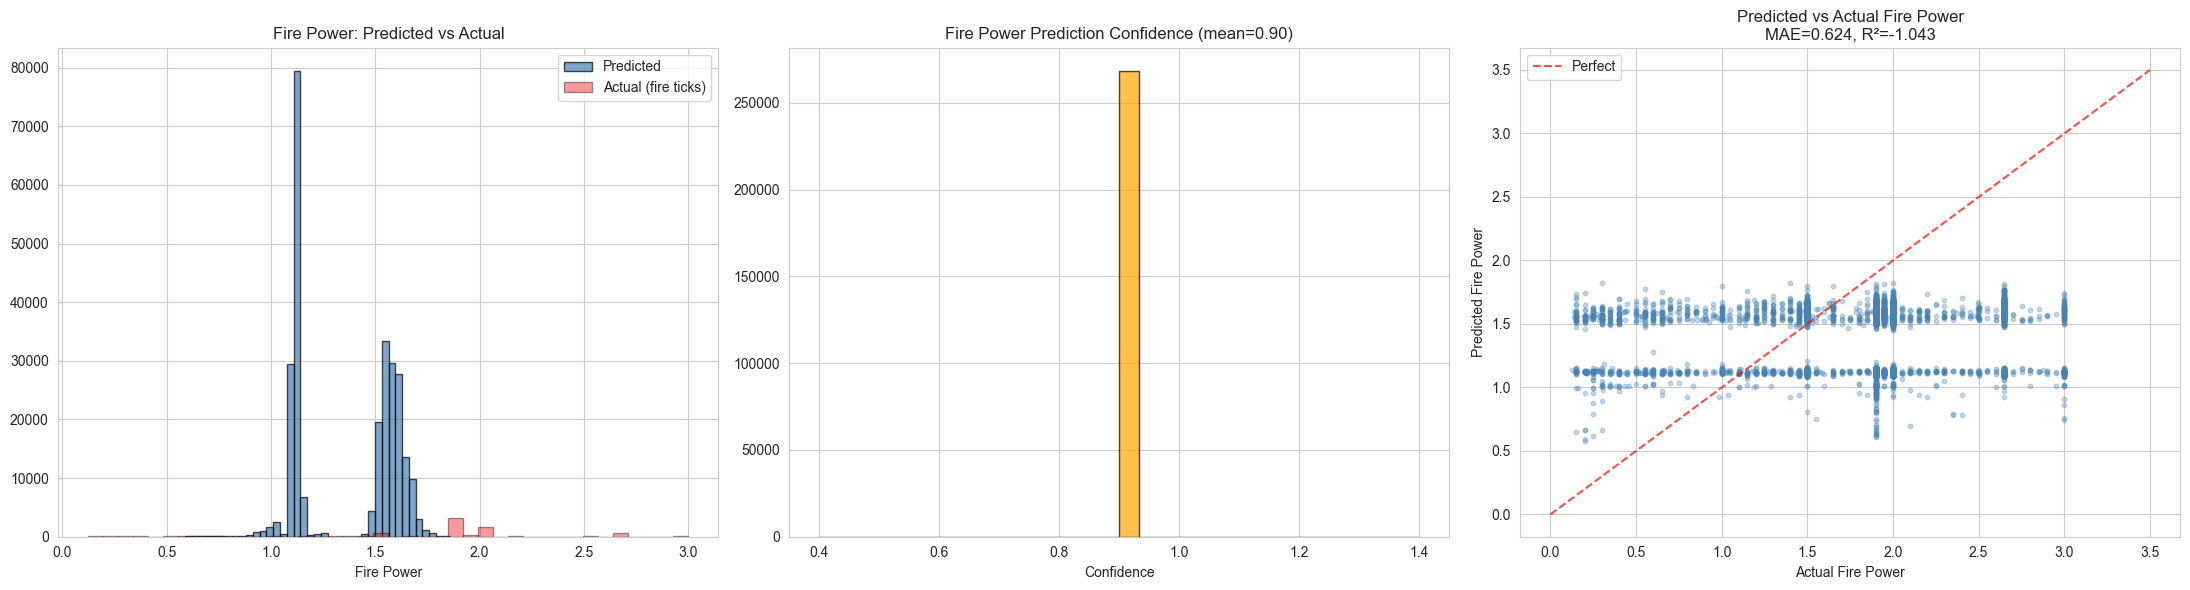

In [2]:
# --- Fire Power Prediction ---
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# 1. Predicted fire power distribution
ax = axes[0]
pred_fp = df['predicted_fire_power'].dropna()
pred_fp.hist(ax=ax, bins=40, color='steelblue', alpha=0.7, edgecolor='black', label='Predicted')
# Overlay actual opponent fire power on fire ticks
actual_fp = df.loc[df['opponent_fired'] == 1, 'opponent_fire_power'].dropna()
if len(actual_fp) > 0:
    actual_fp.hist(ax=ax, bins=40, color='red', alpha=0.4, edgecolor='black', label='Actual (fire ticks)')
ax.set_xlabel('Fire Power')
ax.set_title('Fire Power: Predicted vs Actual')
ax.legend()

# 2. Confidence distribution
ax = axes[1]
conf_fp = df['predicted_fire_power_confidence'].dropna()
conf_fp.hist(ax=ax, bins=30, color='orange', alpha=0.7, edgecolor='black')
ax.set_xlabel('Confidence')
ax.set_title(f'Fire Power Prediction Confidence (mean={conf_fp.mean():.2f})')

# 3. Prediction vs actual on fire ticks
ax = axes[2]
fire_ticks = df[df['opponent_fired'] == 1].dropna(subset=['predicted_fire_power', 'opponent_fire_power'])
if len(fire_ticks) > 0:
    ax.scatter(fire_ticks['opponent_fire_power'], fire_ticks['predicted_fire_power'],
               alpha=0.3, s=10, c='steelblue')
    ax.plot([0, 3.5], [0, 3.5], 'r--', alpha=0.7, label='Perfect')
    from sklearn.metrics import mean_absolute_error, r2_score
    mae = mean_absolute_error(fire_ticks['opponent_fire_power'], fire_ticks['predicted_fire_power'])
    r2 = r2_score(fire_ticks['opponent_fire_power'], fire_ticks['predicted_fire_power'])
    ax.set_title(f'Predicted vs Actual Fire Power\nMAE={mae:.3f}, R\u00b2={r2:.3f}')
    ax.legend()
else:
    ax.set_title('No fire events to compare')
ax.set_xlabel('Actual Fire Power')
ax.set_ylabel('Predicted Fire Power')

plt.tight_layout()
plt.show()

C:\Users\pavelsavara\AppData\Local\Temp\ipykernel_60768\288813189.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cal = valid.groupby('pred_bin').agg(


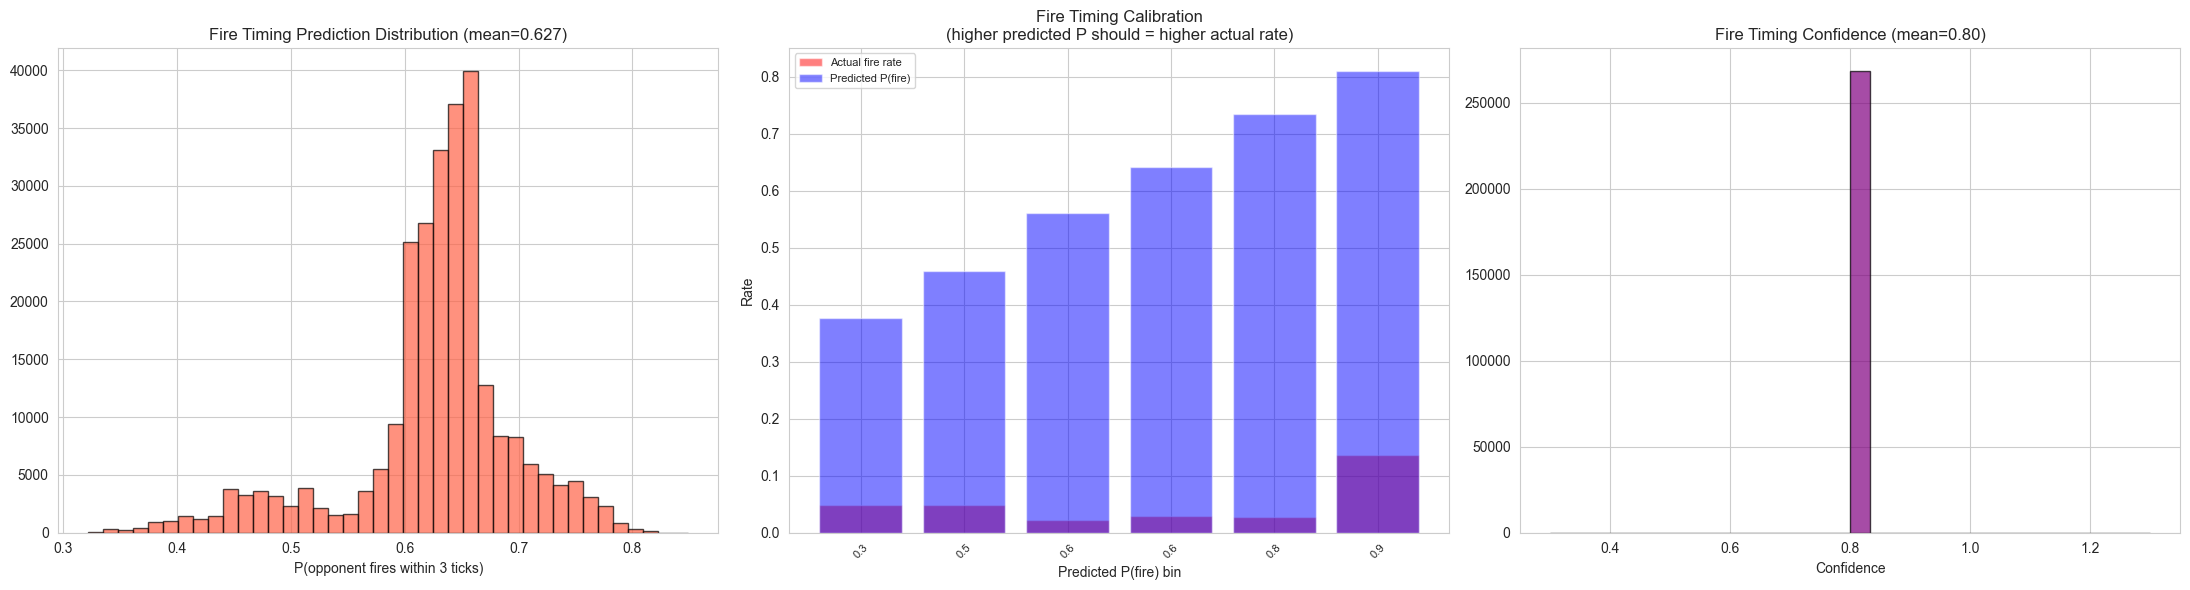

In [3]:
# --- Fire Timing Prediction ---
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# 1. P(fire) distribution
ax = axes[0]
pfire = df['predicted_opponent_fires_3'].dropna()
pfire.hist(ax=ax, bins=40, color='tomato', alpha=0.7, edgecolor='black')
ax.set_xlabel('P(opponent fires within 3 ticks)')
ax.set_title(f'Fire Timing Prediction Distribution (mean={pfire.mean():.3f})')

# 2. Calibration: bin predictions, check actual fire rate
ax = axes[1]
valid = df.dropna(subset=['predicted_opponent_fires_3', 'opponent_fired'])
if len(valid) > 100:
    # Create a "fires within 3 ticks" label by forward-looking (approximate: use opponent_fired)
    valid = valid.copy()
    bins = np.linspace(0, 1, 11)
    valid['pred_bin'] = pd.cut(valid['predicted_opponent_fires_3'], bins=bins)
    cal = valid.groupby('pred_bin').agg(
        pred_mean=('predicted_opponent_fires_3', 'mean'),
        actual_rate=('opponent_fired', 'mean'),
        count=('opponent_fired', 'count'),
    ).dropna()
    ax.bar(range(len(cal)), cal['actual_rate'], alpha=0.5, color='red', label='Actual fire rate')
    ax.bar(range(len(cal)), cal['pred_mean'], alpha=0.5, color='blue', label='Predicted P(fire)')
    ax.set_xticks(range(len(cal)))
    ax.set_xticklabels([f'{b.mid:.1f}' for b in cal.index], rotation=45, fontsize=8)
    ax.set_xlabel('Predicted P(fire) bin')
    ax.set_ylabel('Rate')
    ax.set_title('Fire Timing Calibration\n(higher predicted P should = higher actual rate)')
    ax.legend(fontsize=8)

# 3. Confidence
ax = axes[2]
conf_ft = df['predicted_opponent_fires_3_confidence'].dropna()
conf_ft.hist(ax=ax, bins=30, color='purple', alpha=0.7, edgecolor='black')
ax.set_xlabel('Confidence')
ax.set_title(f'Fire Timing Confidence (mean={conf_ft.mean():.2f})')

plt.tight_layout()
plt.show()

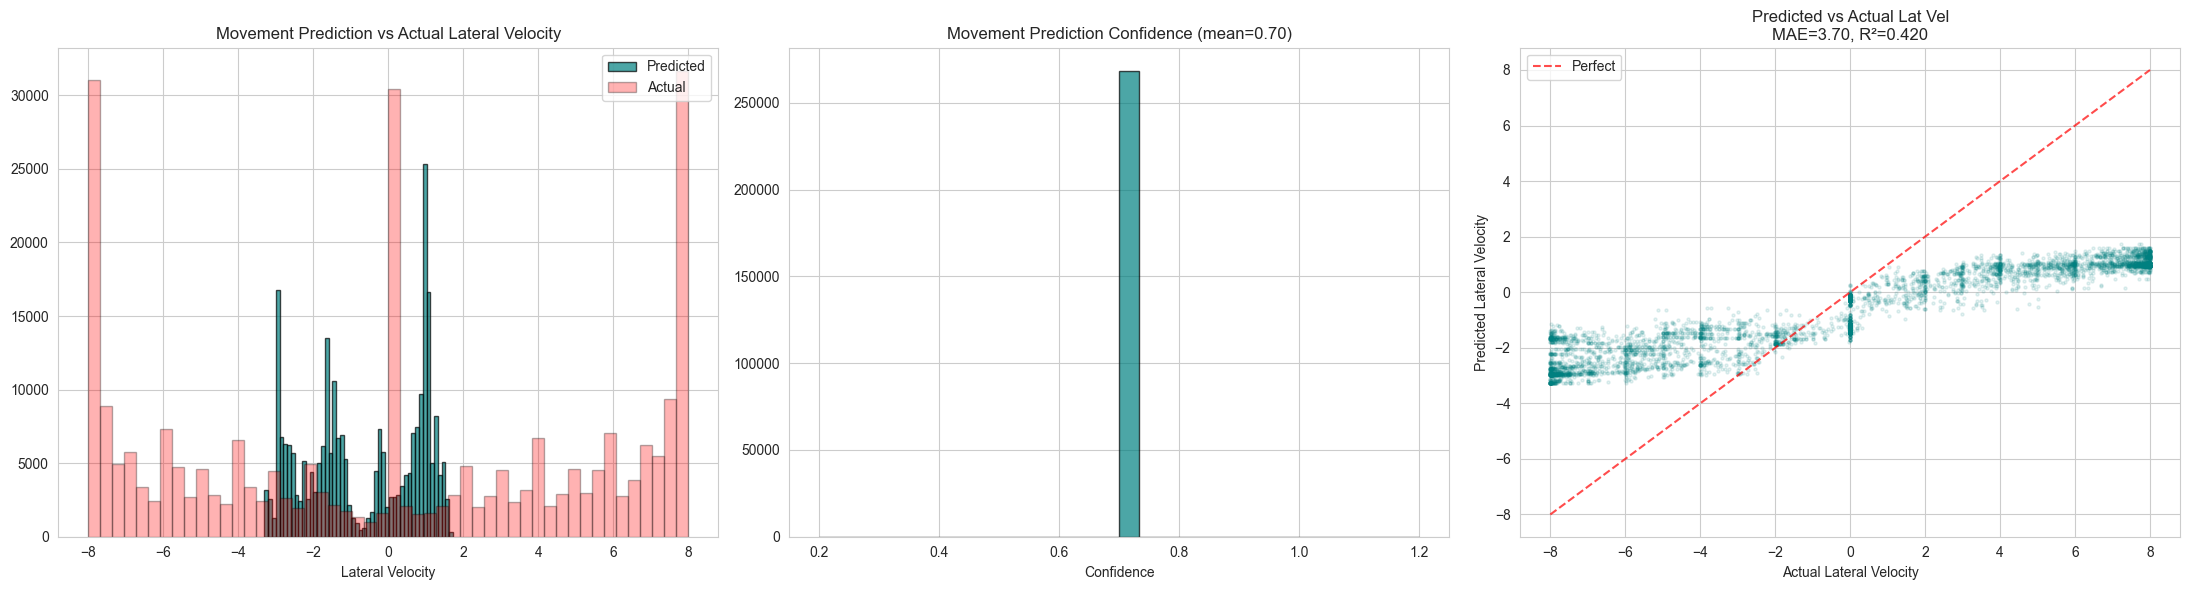

=== ML Prediction Summary ===
Fire Power  — confidence: 0.90, fire ticks available: 7933
  MAE=3.698
Fire Timing — confidence: 0.80, mean P(fire)=0.627
Movement    — confidence: 0.70
  MAE=3.70, R²=0.420


In [4]:
# --- Movement Prediction ---
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# 1. Predicted lateral velocity distribution
ax = axes[0]
plv = df['predicted_lat_vel_5'].dropna()
plv.hist(ax=ax, bins=50, color='teal', alpha=0.7, edgecolor='black', label='Predicted')
actual_lv = df['opponent_lateral_velocity'].dropna()
actual_lv.hist(ax=ax, bins=50, color='red', alpha=0.3, edgecolor='black', label='Actual')
ax.set_xlabel('Lateral Velocity')
ax.set_title('Movement Prediction vs Actual Lateral Velocity')
ax.legend()

# 2. Confidence
ax = axes[1]
conf_mv = df['predicted_lat_vel_5_confidence'].dropna()
conf_mv.hist(ax=ax, bins=30, color='teal', alpha=0.7, edgecolor='black')
ax.set_xlabel('Confidence')
ax.set_title(f'Movement Prediction Confidence (mean={conf_mv.mean():.2f})')

# 3. Scatter: predicted vs actual
ax = axes[2]
valid_mv = df.dropna(subset=['predicted_lat_vel_5', 'opponent_lateral_velocity'])
if len(valid_mv) > 100:
    sample = valid_mv.sample(min(5000, len(valid_mv)), random_state=42)
    ax.scatter(sample['opponent_lateral_velocity'], sample['predicted_lat_vel_5'],
               alpha=0.1, s=5, c='teal')
    ax.plot([-8, 8], [-8, 8], 'r--', alpha=0.7, label='Perfect')
    from sklearn.metrics import mean_absolute_error, r2_score
    mae = mean_absolute_error(valid_mv['opponent_lateral_velocity'], valid_mv['predicted_lat_vel_5'])
    r2 = r2_score(valid_mv['opponent_lateral_velocity'], valid_mv['predicted_lat_vel_5'])
    ax.set_title(f'Predicted vs Actual Lat Vel\nMAE={mae:.2f}, R\u00b2={r2:.3f}')
    ax.legend()
ax.set_xlabel('Actual Lateral Velocity')
ax.set_ylabel('Predicted Lateral Velocity')

plt.tight_layout()
plt.show()

# Summary
print('=== ML Prediction Summary ===')
print(f'Fire Power  — confidence: {conf_fp.mean():.2f}, fire ticks available: {len(fire_ticks)}')
if len(fire_ticks) > 0:
    print(f'  MAE={mae:.3f}')
print(f'Fire Timing — confidence: {conf_ft.mean():.2f}, mean P(fire)={pfire.mean():.3f}')
print(f'Movement    — confidence: {conf_mv.mean():.2f}')
if len(valid_mv) > 0:
    print(f'  MAE={mean_absolute_error(valid_mv["opponent_lateral_velocity"], valid_mv["predicted_lat_vel_5"]):.2f}, R\u00b2={r2_score(valid_mv["opponent_lateral_velocity"], valid_mv["predicted_lat_vel_5"]):.3f}')